#  Diabetes Prediction using Logistic Regression

---

### 📌 Project Overview

In this project, we will **predict whether a person has diabetes** based on health data like age, BMI, blood glucose level, and more.

| Step | What We Do |
|------|------------|
| 1️⃣ | Import Libraries |
| 2️⃣ | Load & Understand the Data |
| 3️⃣ | Exploratory Data Analysis (EDA) |
| 4️⃣ | Prepare Data for ML |
| 5️⃣ | Train Logistic Regression Model |
| 6️⃣ | Evaluate the Model |
| 7️⃣ | Predict on New Data |



---
##  Step 1 — Import Libraries

| Library | Purpose |
|---|---|
| `pandas` | Load and work with data (like Excel in Python) |
| `matplotlib` & `seaborn` | Create charts |
| `sklearn` | Machine Learning algorithms and tools |

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
##  Step 2 — Load the Dataset

In [4]:
from pathlib import Path

import kagglehub
import pandas as pd

file_path = "diabetes_prediction_dataset.csv"
dataset_dir = Path(
    kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")
)
dataset_file = dataset_dir / file_path
df = pd.read_csv(dataset_file)

df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


---
##  Step 3 — Exploratory Data Analysis (EDA)

EDA means **getting to know our data** before training a model.
We check for missing values, understand distributions, and spot patterns.

> 💡 Bad data → Bad model. EDA helps us catch issues early.
- ##### Check for Missing Values
- ##### Summary Statistics Shows count, mean, min, max for all numeric columns
- ##### Target Variable Distribution How many patients have diabetes vs do not?
- ##### Correlation Heatmap -   We want to see which features are most related to 'diabetes'

In [7]:
#summary stats
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Target Variable Distribution:
diabetes
0    91500
1     8500
Name: count, dtype: int64


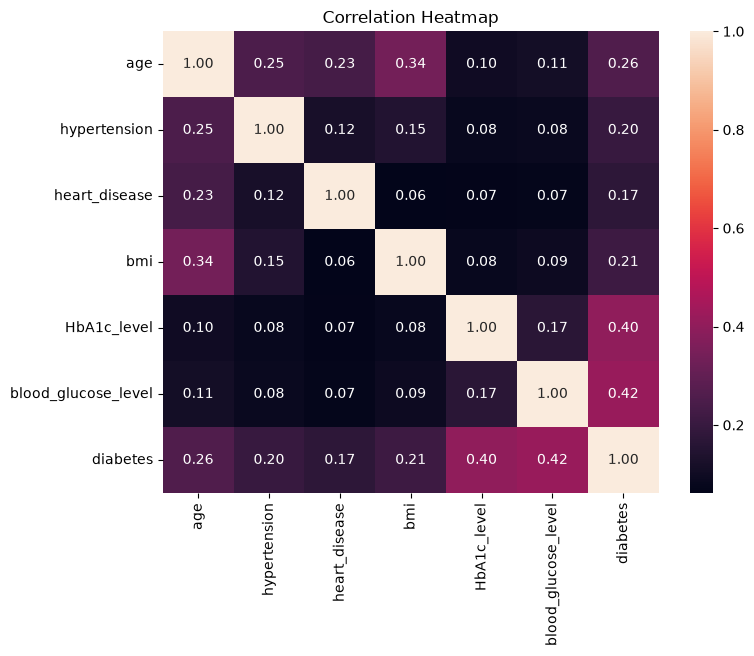

In [8]:
# Summary stats
display(df.describe())

# Target value distribution (class imbalance)
print("Target Variable Distribution:")
print(df['diabetes'].value_counts())

# Correlation Heatmap for numeric columns only
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

---
## 🛠️ Step 4 — Data Preprocessing

ML models need **numbers**, not text. We also split data and scale it.

1. **Encode** text columns → numbers  
2. **Split** into Features `X` and Target `y`  
3. **Train-Test Split** — 80% train, 20% test  
4. **Scale** features so all values are on a similar range

In [9]:
cat_col = df.select_dtypes(include ='object').columns
cat_col

for col in cat_col:
  print(f'{col} : {df[col].unique()}')

gender : ['Female' 'Male' 'Other']
smoking_history : ['never' 'No Info' 'current' 'former' 'ever' 'not current']


In [10]:
df_copy = df.copy()
df_copy = pd.get_dummies( #

        df_copy,
        cat_col,
        drop_first = True,
        dtype = int

)
df_copy.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,0,0,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,1,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,1,0,1,0,0,0,0


In [11]:
#Split X and Y
x = df_copy.drop('diabetes', axis =1) #x = inputs
y = df_copy['diabetes'] #y = outputs


In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0, max_iter=1000)
clf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",0
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in t

---
## 🤖 Step 5 — Train Logistic Regression

**Logistic Regression** is the simplest and most interpretable classification model.

- Despite its name, it is used for **classification** (not regression)
- It predicts the **probability** of a patient having diabetes (0 or 1)
- Always a great starting point for any binary classification problem

In [16]:
y_predict = clf.predict(x_test)
y_predict[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1])

In [17]:
compare = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_predict
})
compare.head(10)


,Actual,Predicted
69456,0,0
86614,0,0
61660,0,0
8558,0,0
4619,0,0
99796,0,0
71346,0,0
75476,1,1
8978,0,0
69354,0,1


---
## 📊 Step 6 — Evaluate the Model

We measure performance using:

| Metric | Meaning |
|--------|----------|
| **Accuracy** | % of correct predictions overall |
| **Precision** | Of all predicted diabetic, how many truly are? |
| **Recall** | Of all actual diabetic patients, how many did we catch? |
| **F1-Score** | Balance between Precision and Recall |

> 🏥 In medical problems, **Recall** matters most — missing a diabetic patient is dangerous!

Accuracy:  0.9604000000
Precision: 0.8592
Recall:    0.6388
F1-Score:  0.7328

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



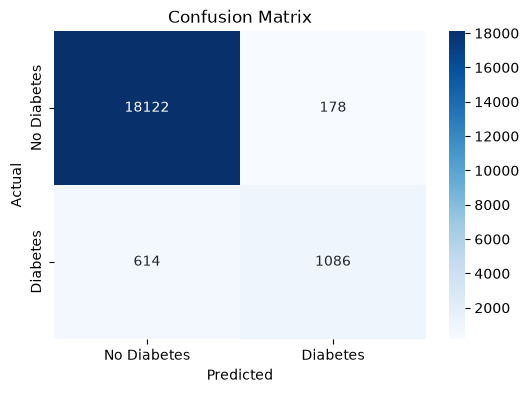

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Predict on the test set
y_pred = clf.predict(x_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.10f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

---
## 🔮 Step 7 — Predict on New Data

We can now use our trained model to predict whether a new patient might have diabetes by passing their health parameters.

In [19]:
# Define a new patient's health parameters
# Let's match the exact feature columns of the training set
new_patient = pd.DataFrame({
    'age': [54.0],
    'hypertension': [0],
    'heart_disease': [0],
    'bmi': [27.3],
    'HbA1c_level': [6.6],
    'blood_glucose_level': [80],
    'gender_Male': [0],
    'gender_Other': [0],
    'smoking_history_current': [0],
    'smoking_history_ever': [0],
    'smoking_history_former': [0],
    'smoking_history_never': [1],
    'smoking_history_not current': [0]
})

# Make prediction
prediction = clf.predict(new_patient)[0]
probability = clf.predict_proba(new_patient)[0][1]

# Print outcome
if prediction == 1:
    print(f"⚠️ The model predicts the patient HAS diabetes (Probability: {probability:.2%})")
else:
    print(f"✅ The model predicts the patient does NOT have diabetes (Probability: {probability:.2%})")

✅ The model predicts the patient does NOT have diabetes (Probability: 1.44%)


In [6]:
from pathlib import Path

dataset_path = Path("diabetes_prediction_dataset_export.csv")
df.to_csv(dataset_path, index=False)
print(f"Dataset exported to {dataset_path}")

Dataset exported to diabetes_prediction_dataset_export.csv
